In [1]:
import hoomd
import hoomd.md
import hoomd.write
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [2]:
def load_hydropathy(scale_name):
    project_root = Path.cwd().parent
    yaml_path = project_root / "configs" / "simulation" / "hydropathy_scales.yaml"
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    return data[scale_name]

In [3]:
AA_ORDER = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I', 
            'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
hps_dict = load_hydropathy("HPS1")
missing = set(AA_ORDER) - set(hps_dict.keys())
if missing:
    raise ValueError(f"Hydropathy scale is missing values for: {missing}")
    
ids = {aa: i for i, aa in enumerate(AA_ORDER)}

hps = np.array([hps_dict[aa] for aa in AA_ORDER])

masses = np.array([71.08, 156.2, 114.1, 115.1, 103.1, 128.1, 129.1, 57.05, 137.1, 113.2
, 113.2, 128.2, 131.2, 147.2, 97.12, 87.08, 101.1, 186.2, 163.2, 99.07], dtype=np.float32)

charges = np.array([0.0, 1.0, 0.0, -1.0, 0.0, 0.0, -1.0, 0.0, 0.5, 0.0, 0.0, 1.0, 0.0, 0.0
, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)

sigma = np.array([0.504, 0.656, 0.568, 0.558, 0.548, 0.602, 0.592, 0.45, 0.608, 0.618, 0.618, 0.636
 , 0.618, 0.636, 0.556, 0.518, 0.562, 0.678, 0.646, 0.586], dtype=np.float32)

print(hps)

[0.73  0.    0.432 0.378 0.595 0.514 0.459 0.649 0.514 0.973 0.973 0.514
 0.838 1.    1.    0.595 0.676 0.946 0.865 0.892]


In [4]:
def populate_snapshot(snapshot, sequence):
    
    sqid = np.array([ids[aa] for aa in sequence], dtype=np.int32)
    N = len(sequence)

    # Particles
    snapshot.particles.typeid[:] = sqid
    snapshot.particles.mass[:]   = masses[sqid]
    snapshot.particles.charge[:] = charges[sqid]
    snapshot.particles.diameter[:] = sigma[sqid]

    # Place beads in a straight line with ~0.38 nm spacing (realistic Cα-Cα)
    snapshot.particles.position[:] = [[i * 0.38 - (N * 0.38) / 2, 0, 0] for i in range(N)]

    # Bonds: chain connectivity
    snapshot.bonds.N = N - 1
    snapshot.bonds.types = ['AA-bond']
    snapshot.bonds.typeid[:] = [0] * (N - 1)
    snapshot.bonds.group[:]  = [[i, i + 1] for i in range(N - 1)]

    return snapshot

In [28]:

# ── Settings ──────────────────────────────────────────────────────────────────
SEQUENCE  = 'NLYIQWLKDGGPSSGRPPPS'
GSD_FILE  = 'trajectory.gsd'
BOX_SIZE  = 30.0      # nm, appropriate for a 23-residue chain
KT        = 1.0       # reduced units, ~room temp in HPS
DT        = 0.005     # timestep
N_STEPS   = 100000
SAVE_EVERY= 1000      # save frame every N steps -> 100 frames total
EPS_HPS   = 0.2       # kJ/mol, fixed LJ epsilon for all pairs
# ──────────────────────────────────────────────────────────────────────────────

In [29]:
def calculate_rg(positions):
    """
    positions: numpy array of shape (N, 3)
    """
    # 1. Calculate center of mass
    center_of_mass = np.mean(positions, axis=0)
    
    # 2. Calculate squared distances from center of mass
    sq_distances = np.sum((positions - center_of_mass)**2, axis=1)
    
    # 3. Square root of the mean
    return np.sqrt(np.mean(sq_distances))

In [30]:
# ── Build snapshot ────────────────────────────────────────────────────────────
N = len(SEQUENCE)
device = hoomd.device.auto_select()
sim = hoomd.Simulation(device=device, seed=42)

snapshot = hoomd.Snapshot()
snapshot.configuration.box = [BOX_SIZE, BOX_SIZE, BOX_SIZE, 0, 0, 0]
snapshot.particles.types = AA_ORDER
snapshot.particles.N = N
snapshot.bonds.N = N - 1      # must pre-allocate before populate_snapshot
snapshot.bonds.types = ['AA-bond']
populate_snapshot(snapshot, SEQUENCE)

sim.create_state_from_snapshot(snapshot)



In [31]:
# ── Forces ────────────────────────────────────────────────────────────────────
nl = hoomd.md.nlist.Tree(buffer=0.2)
lj = hoomd.md.pair.LJ(nlist=nl)

# HPS pair interactions: WCA (repulsive) if mean hydropathy < 0.5, else full LJ
for i, aa1 in enumerate(AA_ORDER):
    for j, aa2 in enumerate(AA_ORDER):
        if j < i:
            continue
        sig_ij = (sigma[i] + sigma[j]) / 2
        lam_ij = (hps[i]   + hps[j])   / 2
        lj.params[(aa1, aa2)] = dict(epsilon=EPS_HPS, sigma=sig_ij)
        if lam_ij < 0.5:
            lj.r_cut[(aa1, aa2)] = 2**(1/6) * sig_ij   # purely repulsive (WCA)
        else:
            lj.r_cut[(aa1, aa2)] = 2.5 * sig_ij        # attractive

# FENE bonds for chain connectivity
fene = hoomd.md.bond.FENEWCA()
fene.params['AA-bond'] = dict(k=30.0, r0=1.5, epsilon=1.0, sigma=0.47, delta=0.0)


In [32]:
# ── Integrator ────────────────────────────────────────────────────────────────
langevin = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=KT)
sim.operations.integrator = hoomd.md.Integrator(
    dt=DT,
    methods=[langevin],
    forces=[lj, fene]
)

# ── Writer ────────────────────────────────────────────────────────────────────
gsd_writer = hoomd.write.GSD(
    filename=GSD_FILE,
    trigger=hoomd.trigger.Periodic(SAVE_EVERY),
    mode='wb'
)
sim.operations.writers.append(gsd_writer)



In [33]:
print(f"Running HPS simulation for {N_STEPS} steps...")
print(f"Sequence: {SEQUENCE} ({N} residues)")
print(f"Saving every {SAVE_EVERY} steps -> {N_STEPS // SAVE_EVERY} frames to {GSD_FILE}\n")

sim.run(N_STEPS)
# Force flush to disk
gsd_writer.flush()
print("Wrote", GSD_FILE)
print("Simulation complete!")


Running HPS simulation for 100000 steps...
Sequence: NLYIQWLKDGGPSSGRPPPS (20 residues)
Saving every 1000 steps -> 100 frames to trajectory.gsd

Wrote trajectory.gsd
Simulation complete!


Loading trajectory...
Total frames: 100, rendering 100 frames.
Rendering animation (this may take a minute)...

Done! Video saved to: idp_movie.mp4


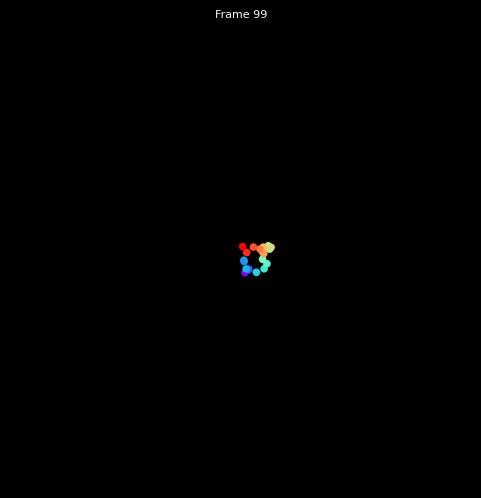

In [34]:
"""
render_matplotlib.py
Renders a GSD trajectory to a movie using only gsd + matplotlib.
"""
import gsd.hoomd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# ── Settings ──────────────────────────────────────────────────────────────────
GSD_FILE  = "trajectory.gsd"
MOVIE_OUT = "idp_movie.mp4"
EVERY_NTH = 1       # increase to skip frames and speed things up
FPS       = 24
DPI       = 100     # increase for higher resolution
DOT_SIZE  = 20      # size of each bead
# ──────────────────────────────────────────────────────────────────────────────

print("Loading trajectory...")
traj = gsd.hoomd.open(GSD_FILE, 'r')
frames = list(range(0, len(traj), EVERY_NTH))
print(f"Total frames: {len(traj)}, rendering {len(frames)} frames.")

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.set_facecolor('black')
fig.patch.set_facecolor('black')
ax.axis('off')

# Use the first frame to set axis limits from the box size
first = traj[0]
box = first.configuration.box  # [Lx, Ly, Lz, xy, xz, yz]
ax.set_xlim(-box[0]/2, box[0]/2)
ax.set_ylim(-box[1]/2, box[1]/2)

# Color beads by index along the chain (looks great for polymers)
n_particles = first.particles.N
colors = plt.cm.rainbow(np.linspace(0, 1, n_particles))

pos0 = first.particles.position
scat = ax.scatter(pos0[:, 0], pos0[:, 1], s=DOT_SIZE, c=colors)

def update(frame_idx):
    snap = traj[frame_idx]
    pos = snap.particles.position  # shape (N, 3)
    scat.set_offsets(pos[:, :2])   # project onto XY plane
    ax.set_title(f"Frame {frame_idx}", color='white', fontsize=8)
    return (scat,)

print("Rendering animation (this may take a minute)...")
ani = animation.FuncAnimation(
    fig, update,
    frames=frames,
    blit=True,
    interval=1000 / FPS
)

writer = animation.FFMpegWriter(fps=FPS)
ani.save(MOVIE_OUT, writer=writer, dpi=DPI,
         savefig_kwargs={'facecolor': 'black'})

traj.close()
print(f"\nDone! Video saved to: {MOVIE_OUT}")